In [1]:
import pandas as pd
import numpy as np
import torch
import os
import sys
from tqdm import tqdm, trange
import time
import copy
sys.path.append("../../")

print("Current working directory:", os.getcwd())

from biked_commons.design_evaluation.design_evaluation import *
from biked_commons.conditioning import conditioning
from biked_commons.resource_utils import split_datasets_path
from biked_commons.design_evaluation.scoring import *

# os.chdir("src")
# print("Current working directory:", os.getcwd())

import argparse
import torch
import numpy as np
from matplotlib import pyplot as plt
from importlib import invalidate_caches
invalidate_caches()

from biked_commons.benchmark_models.libmoon.solver.gradient import MGDASolver, GradAggSolver, EPOSolver, MOOSVGDSolver, GradHVSolver, PMTLSolver
from biked_commons.benchmark_models.libmoon.util_global.constant import problem_dict
from biked_commons.benchmark_models.libmoon.util_global.weight_factor.funs import uniform_pref
from biked_commons.benchmark_models.libmoon.visulization.view_res import vedio_res
from biked_commons.benchmark_models.libmoon.problem.mop import mop

import sys
print(sys.version)

Current working directory: c:\Users\Lyler\Documents\biked-commons\src\biked_commons\benchmark_models


c:\Users\Lyler\mambaforge\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Lyler\mambaforge\envs\torch\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Lyler\Documents\biked-commons\src\biked_commons\benchmark_models\../..\biked_commons\prediction\usability_predictors.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which

3.12.8 | packaged by conda-forge | (main, Dec  5 2024, 14:06:27) [MSC v.1942 64 bit (AMD64)]


In [2]:
data = pd.read_csv(split_datasets_path("bike_bench.csv"), index_col=0)

len(data.columns)

97

In [3]:
def get_condition(idx=0):
    rider_condition = conditioning.sample_riders(10, split="test")
    use_case_condition = conditioning.sample_use_case(10, split="test")
    image_embeddings = conditioning.sample_image_embedding(10, split="test")
    condition = {"Rider": rider_condition[idx], "Use Case": use_case_condition[idx], "Embedding": image_embeddings[idx]}
    return condition

In [56]:
class bicycle(mop):
    def __init__(self, data_sample_df, conditioning, n_obj_override=5):
        evaluator, requirement_names, requirement_types = construct_tensor_evaluator(StandardEvaluations, data_sample_df.columns)
        data_sample = data_sample_df.to_numpy()
        
        self.conditioning = conditioning

        self.evaluator=evaluator
        self.requirement_names=requirement_names
        isobjective = torch.tensor(requirement_types) == 1
        self.isobjective = isobjective
        objective_names = np.array(requirement_names)[isobjective]
        ref_point = get_ref_point(evaluator, objective_names, isobjective)

        n_var = data_sample.shape[1]
        n_obj = len(requirement_names) 
        n_obj = np.minimum(n_obj, n_obj_override)
        lbound = np.min(data_sample, axis=0)
        ubound = np.max(data_sample, axis=0)
        super().__init__(n_var=n_var,
                         n_obj=n_obj,
                         lbound=lbound,
                         ubound=ubound, )
        self.problem_name = 'bicycle'
        self.condition = conditioning
        # self.ref_point = torch.tensor(ref_point[:self.n_obj], dtype=torch.float32)
    
    def evaluate_fn(self, X):
        X_tens = torch.tensor(X, dtype=torch.float32)
        eval_scores = self.evaluator(X_tens, self.conditioning)
        objective_scores = eval_scores[:, self.isobjective]
        constraint_scores = eval_scores[:, ~self.isobjective]
        # constraint_validity_mask = torch.all(constraint_scores <= 0, axis=1)
        # ref_point_full = torch.tile(self.ref_point, (X.shape[0], 1))
        # print(constraint_validity_mask.shape, objective_scores.shape, ref_point_full.shape)
        # objective_scores[~constraint_validity_mask] = ref_point_full[~constraint_validity_mask]
        # all_scores = torch.concat([objective_scores, constraint_scores], axis=1)

        # return all_scores[:, -self.n_obj:]

        return constraint_scores[:, -self.n_obj:]

    def _evaluate_torch(self, x): # All scores should be minimised
        return  self.evaluate_fn(x)

In [63]:
condition = get_condition(0)

parser = argparse.ArgumentParser(description='example')
parser.add_argument('--n-partition', type=int, default=2)
parser.add_argument('--agg', type=str, default='tche')
parser.add_argument('--solver', type=str, default='agg')
parser.add_argument('--problem-name', type=str, default='VLMOP2')
parser.add_argument('--iter', type=int, default=1000)
parser.add_argument('--step-size', type=float, default=1e-2)
parser.add_argument('--tol', type=float, default=1e-6)

args = parser.parse_args(args=[
    '--n-partition', '10',
    '--agg', 'tche',
    '--solver', 'agg',
    '--iter', '100',
    
    '--step-size', '0.01',
    '--tol', '1e-6'
])

evaluator, requirement_names, requirement_types = construct_tensor_evaluator(StandardEvaluations, data.columns)


solver = GradAggSolver(args.step_size, args.iter, args.tol)
problem = bicycle(data_sample_df=data, conditioning=condition)

prefs = uniform_pref(args.n_partition, problem.n_obj, clip_eps=1e-2)
x0 = torch.tensor(data.iloc[0].to_numpy())

data_tens = torch.tensor(data.to_numpy(), dtype=torch.float32)
dataset_scores = problem._evaluate_torch(data_tens)
ref_point = np.max(dataset_scores.detach().cpu().numpy(), axis=0)

res = solver.solve(problem, x=x0, prefs=prefs, args=args, ref_point=ref_point)

100%|██████████| 100/100 [00:08<00:00, 11.78it/s]


In [ ]:
initial = problem._evaluate_torch(x0.unsqueeze(0))
final = problem._evaluate_torch(torch.tensor(res['x']).unsqueeze(0))

print("Initial design:", x0)
print("Final design:", res['x'])
print("Initial scores:", initial)
print("Final scores:", final)

Initial design: tensor([430.0000,  67.0000, 608.3238,  73.0000, 135.6000,  45.0000, 588.7000,
         72.5000, 664.0207,  45.0000,  40.0000,  32.5000,  38.4500,  23.3500,
         13.0000,  15.0000,   7.0000,  40.0000,  28.7000,  50.0000, 330.0000,
        350.0000,  16.0000,  18.0000,   0.0000,   0.0000, 130.0000,   2.0000,
          0.9000,   1.1000,   0.9000,   1.2000,   1.0000,   0.9000, 689.0000,
         67.0000, 689.0000,  67.0000,   0.0000,  68.0000,  45.0000, 692.0000,
         34.0000,   0.0000,   0.0000,   9.0000,   1.0000,   0.0000, 255.0000,
          0.0000,   0.0000,   1.0000,   1.0000,  80.0000,  80.0000, 298.0000,
        768.0000,  34.9000, 300.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          1.0000,   0.0000,   0.0000,   0.0000,   1.0000,   0.0000,   1.0000,
          0.0000,   0.0000,   1.0000,   0.0000,   0.0000,   1.0000,   0.0000,
          0.0000,   0.0000,   1.0000,   0.0000,   0.0000,   1.0000,   0.0000,
          1.0000,   0.0000,   0.0000,   1.0000, 

In [ ]:
def test_all(args, condition, x0, prefs):
    print("Testing solely aero")
    evaluator, requirement_names, requirement_types = construct_tensor_evaluator(StandardEvaluations, data.columns)
    isobjective = torch.tensor(requirement_types) == 1
    objective_names = requirement_names[isobjective]
    ref_point = get_ref_point(evaluator, objective_names, isobjective)

    def eval_fn(x, condition): # All scores should be minimised
        return evaluator(x, condition)


    solver = GradAggSolver(args.step_size, args.iter, args.tol)
    problem = bicycle(condition=condition, eval_fn=eval_fn)

    res = solver.solve(problem, x=x0, prefs=prefs, args=args, ref_point=ref_point)

    ####### Checking improvements #######

    diff = res['x'][0] - x0.numpy()
    print('Number of parameters affacted', np.count_nonzero(diff))
    initial = evaluator(x0, condition)
    final = evaluator(torch.tensor(res['x']), condition) 

    print('Score initial: ', initial)
    print('Score final: ', final)

    if initial > final:
        print("Score improved")
    else:
        print("Score not improved")

In [ ]:
num_data = 1
rider_condition = conditioning.sample_riders(num_data, split="test")
use_case_condition = conditioning.sample_use_case(num_data, split="test")
text_condition = conditioning.sample_text(num_data, split="test")

parser = argparse.ArgumentParser(description='example')
parser.add_argument('--n-partition', type=int, default=10)
parser.add_argument('--agg', type=str, default='tche')
parser.add_argument('--solver', type=str, default='agg')
parser.add_argument('--problem-name', type=str, default='VLMOP2')
parser.add_argument('--iter', type=int, default=1000)
parser.add_argument('--step-size', type=float, default=1e-2)
parser.add_argument('--tol', type=float, default=1e-6)

args = parser.parse_args(args=[
    '--n-partition', '10',
    '--agg', 'tche',
    '--solver', 'agg',
    '--iter', '1000',
    '--step-size', '0.01',
    '--tol', '1e-6'
])
args.n_var = data.shape[1]

num_objectives = 2
args.n_obj = num_objectives
prefs = uniform_pref(args.n_partition, num_objectives, clip_eps=1e-2)  # Two Objective
args.n_prob = len(prefs)

prefs = uniform_pref(args.n_partition, num_objectives, clip_eps=1e-2)  # Two Objective

x0 = torch.rand(args.n_prob, data.shape[1])

solver = GradAggSolver(args.step_size, args.iter, args.tol)

res = test_all(args, condition, x0, prefs, solver)

In [ ]:
from numpy import array


def test_solely_usability(args, condition, x0, prefs):
    print("Testing solely usability")
    usableEV = [
        UsabilityEvaluator(),
    ]
    evaluator_usable, _, _ = construct_tensor_evaluator(usableEV, data.columns)

    def eval_fn(x, condition): # All scores should be minimised
        return 1- evaluator_usable(x, condition)

    solver = GradAggSolver(args.step_size, args.iter, args.tol)
    problem = bicycle(condition=condition, eval_fn=eval_fn)

    res = solver.solve(problem, x=x0, prefs=prefs, args=args, ref_point=array([ 1.0 ]))

    ####### Checking improvements #######

    # Should only have affacted 3 parameters
    diff = res['x'][0] - x0.numpy()
    print('Number of parameters affacted', np.count_nonzero(diff))
    initial_usability = evaluator_usable(x0, condition)
    final_usability = evaluator_usable(torch.tensor(res['x']), condition)  

    print('Usability score initial: ', initial_usability)
    print('Usability score final: ', final_usability)

    if initial_usability < final_usability:
        print("Usability score improved")
    else:
        print("Usability score not improved")


def test_solely_aero(args, condition, x0, prefs):
    print("Testing solely aero")
    aeroEV = [
        AeroEvaluator(),
    ]
    evaluator, _, _ = construct_tensor_evaluator(aeroEV, data.columns)

    def eval_fn(x, condition): # All scores should be minimised
        return evaluator(x, condition)


    solver = GradAggSolver(args.step_size, args.iter, args.tol)
    problem = bicycle(condition=condition, eval_fn=eval_fn)

    res = solver.solve(problem, x=x0, prefs=prefs, args=args, ref_point=array([ 25.0 ]))

    ####### Checking improvements #######

    diff = res['x'][0] - x0.numpy()
    print('Number of parameters affacted', np.count_nonzero(diff))
    initial = evaluator(x0, condition)
    final = evaluator(torch.tensor(res['x']), condition) 

    print('Score initial: ', initial)
    print('Score final: ', final)

    if initial > final:
        print("Score improved")
    else:
        print("Score not improved")


def test_usability_aero(args, condition, x0, prefs, solver):

    print("Testing combined usability and aero")
    aeroEV = [
        AeroEvaluator(),
    ]
    usableEV = [
        UsabilityEvaluator(),
    ]
    evaluator_aero, _, _ = construct_tensor_evaluator(aeroEV, data.columns)
    evaluator_usable, _, _ = construct_tensor_evaluator(usableEV, data.columns)

    def eval_fn(x, condition): # All scores should be minimised
        usable_score = 1 - evaluator_usable(x, condition)
        aero_score = evaluator_aero(x, condition)
        comb = torch.cat((usable_score, aero_score), dim=1)
        return comb


    problem = bicycle(condition=condition, n_obj=2, eval_fn=eval_fn)

    start_time = time.time()
    res = solver.solve(problem, x=x0, prefs=prefs, args=args, ref_point=array([1.0 , 25.0 ]))  # ref_point used for HV
    end_time = time.time()
    print(f"Time completed: {end_time - start_time:.2f} seconds")

    ####### Checking improvements #######
    x0_np = x0.numpy() if isinstance(x0, torch.Tensor) else x0
    res_x_np = res['x'].numpy() if isinstance(res['x'], torch.Tensor) else res['x']

    assert x0_np.shape == res_x_np.shape, "The shapes of x0 and res['x'] must match"

    num_affected = 0
    for i in range(x0_np.shape[0]):  # Iterate over rows
        diff = np.count_nonzero(res_x_np[i] != x0_np[i])  
        num_affected += diff  

    print('Average Number of parameters affected:', num_affected/x0.shape[0])

    condition_test = {
        "Rider": condition["Rider"][0:1],
        "Use Case": condition["Use Case"][0:1], 
        "Text": condition["Text"][0:1]
    }   

    aero_improved = 0
    usability_improved = 0

    aero_valid_counter = 0
    usability_valid_counter = 0
    for x0_row, res_row in zip(x0, res['x']):
        initial_aero = evaluator_aero(x0_row.unsqueeze(0), condition_test)
        final_aero = evaluator_aero(torch.tensor(res_row).unsqueeze(0), condition_test)  
        initial_usability = evaluator_usable(x0_row.unsqueeze(0), condition_test)
        final_usability = evaluator_usable(torch.tensor(res_row).unsqueeze(0), condition_test)  

        if not torch.isnan(initial_aero).any():
            aero_valid_counter += 1
            if initial_aero > final_aero :
                aero_improved += 1

        if not torch.isnan(initial_usability).any():
            usability_valid_counter += 1    
            if initial_usability < final_usability :
                usability_improved += 1

    if aero_valid_counter == 0:
        print("No valid aero scores found")
    else:
        print('Aero score improved: ', aero_improved/aero_valid_counter)

    if usability_valid_counter == 0:
        print("No valid usability scores found")
    else:
        print('Usability score improved: ', usability_improved/usability_valid_counter)
    return res

In [ ]:
parser = argparse.ArgumentParser(description='example')
parser.add_argument('--n-partition', type=int, default=10)
parser.add_argument('--agg', type=str, default='tche')
parser.add_argument('--solver', type=str, default='agg')
parser.add_argument('--problem-name', type=str, default='VLMOP2')
parser.add_argument('--iter', type=int, default=1000)
parser.add_argument('--step-size', type=float, default=1e-2)
parser.add_argument('--tol', type=float, default=1e-6)

args = parser.parse_args(args=[
    '--n-partition', '10',
    '--agg', 'tche',
    '--solver', 'agg',
    '--iter', '1000',
    '--step-size', '0.01',
    '--tol', '1e-6'
])
args.n_var = data.shape[1]


num_data = 1
rider_condition = conditioning.sample_riders(num_data, split="test")
use_case_condition = conditioning.sample_use_case(num_data, split="test")
text_condition = conditioning.sample_text(num_data, split="test")

############### Single Objective #######################

num_objectives = 1
prefs = uniform_pref(args.n_partition, num_objectives, clip_eps=1e-2)  # Single Objective
args.n_prob = len(prefs)
condition = {
    "Rider": torch.cat([rider_condition] * prefs.shape[0], dim=0),
    "Use Case": torch.cat([use_case_condition] * prefs.shape[0], dim=0),
    "Text": text_condition * prefs.shape[0]
}

# # Initialize the initial solution 
x0 = torch.rand(args.n_prob, data.shape[1])

test_solely_usability(args, condition, x0, prefs)

test_solely_aero(args, condition, x0, prefs)

############### Multi Objective #######################

num_objectives = 2
args.n_obj = num_objectives
prefs = uniform_pref(args.n_partition, num_objectives, clip_eps=1e-2)  # Two Objective
args.n_prob = len(prefs)
condition = {
    "Rider": torch.cat([rider_condition] * prefs.shape[0], dim=0),
    "Use Case": torch.cat([use_case_condition] * prefs.shape[0], dim=0),
    "Text": text_condition * prefs.shape[0]
}
prefs = uniform_pref(args.n_partition, num_objectives, clip_eps=1e-2)  # Two Objective

x0 = torch.rand(args.n_prob, data.shape[1])

solver = GradAggSolver(args.step_size, args.iter, args.tol)

res = test_usability_aero(args, condition, x0, prefs, solver)



Testing solely usability


100%|██████████| 1000/1000 [00:01<00:00, 703.37it/s]


Number of parameters affacted 3
Usability score initial:  tensor([[0.4989]], grad_fn=<CopySlices>)
Usability score final:  tensor([[0.5590]], grad_fn=<CopySlices>)
Usability score improved
Testing solely aero


100%|██████████| 1000/1000 [00:05<00:00, 186.77it/s]


Number of parameters affacted 7
Score initial:  tensor([[9.2952]], grad_fn=<CopySlices>)
Score final:  tensor([[9.2784]], grad_fn=<CopySlices>)
Score improved
Testing combined usability and aero


100%|██████████| 1000/1000 [00:06<00:00, 158.89it/s]


Time completed: 6.30 seconds
Average Number of parameters affected: 6.1
Aero score improved:  1.0
Usability score improved:  0.7


In [ ]:
parser = argparse.ArgumentParser(description='example')
parser.add_argument('--n-partition', type=int, default=10)
parser.add_argument('--agg', type=str, default='tche')
parser.add_argument('--iter', type=int, default=2000)
parser.add_argument('--step-size', type=float, default=0.1)
parser.add_argument('--tol', type=float, default=1e-6)
parser.add_argument('--plt-pref-flag', type=str, default='N')

args = parser.parse_args(args=[
    '--n-partition', '100',
    '--agg', 'ls',            # Only usded for the 'agg' solver  'cosmos', 'pbi' , 'tche','mtche','ls'
    '--iter', '1000',
    '--step-size', '0.01',
    '--tol', '1e-6'
])
args.n_var = data.shape[1]

num_data = 1
rider_condition = conditioning.sample_riders(num_data, split="test")
use_case_condition = conditioning.sample_use_case(num_data, split="test")
text_condition = conditioning.sample_text(num_data, split="test")

################ Multiple Solver Tests #######################
solver_list = [ 'agg',  ]
# 'mgda', 'agg', 'epo', 'moosvgd','hvgrad', 'pmtl'
# 

num_objectives = 2
args.n_obj = num_objectives
prefs = uniform_pref(args.n_partition, num_objectives, clip_eps=1e-2)  # Two Objective
args.n_prob = len(prefs)
condition = {
    "Rider": torch.cat([rider_condition] * prefs.shape[0], dim=0),
    "Use Case": torch.cat([use_case_condition] * prefs.shape[0], dim=0),
    "Text": text_condition * prefs.shape[0]
}
prefs = uniform_pref(args.n_partition, num_objectives, clip_eps=1e-2)  # Two Objective


aeroEV = [
    AeroEvaluator(),
]
condition_test = {
    "Rider": condition["Rider"][0:1],
    "Use Case": condition["Use Case"][0:1], 
    "Text": condition["Text"][0:1]
}   
evaluator_aero, _, _ = construct_tensor_evaluator(aeroEV, data.columns)
x0_list = []  # Store valid rows

while len(x0_list) < args.n_prob:               # Generate new random until we have enough valid rows                
    candidate_row = torch.rand(1, data.shape[1])  
    aero_score = evaluator_aero(candidate_row, condition_test)
    if not torch.isnan(aero_score).any():
        x0_list.append(candidate_row)
x0 = torch.cat(x0_list, dim=0)  


# while True:                                         # Generates duplicate rows                   
#     candidate_row = torch.rand(1, data.shape[1])
#     aero_score = evaluator_aero(candidate_row, condition_test)
#     if not torch.isnan(aero_score).any():
#         break  # Found a valid one
# x0_list = [candidate_row.clone() for _ in range(args.n_prob)]


x0 = torch.cat(x0_list, dim=0)  

res = None
for solver_name in solver_list:
    print(f"Testing solver: {solver_name}")
    if solver_name == 'mgda':                                          
        solver = MGDASolver(args.step_size, args.iter, args.tol)
    elif solver_name == 'agg':                                          
        solver = GradAggSolver(args.step_size, args.iter, args.tol)
    elif solver_name == 'epo':
        solver = EPOSolver(args.step_size, args.iter, args.tol)        # Sensitive to NaN values (aero breaks it)
    elif solver_name == 'moosvgd':
        solver = MOOSVGDSolver(args.step_size, args.iter, args.tol)    # apparently unstable according to authors   
    elif solver_name == 'hvgrad':
        solver = GradHVSolver(args.step_size, args.iter, args.tol)    # Only supports 2 objectives
    elif solver_name == 'pmtl':
        solver = PMTLSolver(args.step_size, args.iter, args.tol)     # Only supports 2 objectives  (not working)
    else:
        raise Exception('solver not supported')

    res = test_usability_aero(
    copy.deepcopy(args),          
    {k: (v.clone() if isinstance(v, torch.Tensor) else copy.deepcopy(v)) for k, v in condition.items()},
    x0.clone(),                   
    prefs.copy(),                
    solver 
)


Testing solver: agg
Testing combined usability and aero


100%|██████████| 1000/1000 [00:07<00:00, 141.60it/s]


Time completed: 7.06 seconds
Average Number of parameters affected: 7.17
Aero score improved:  0.8
Usability score improved:  0.99


In [ ]:
res['y']

array([[ 5.7076055e-01,  4.6458716e+00],
       [ 7.0760936e-01,  8.8921165e+00],
       [ 5.8059800e-01,  4.6312418e+00],
       [ 4.8614955e-01,  9.2741718e+00],
       [ 1.5406473e+00,  8.3636589e+00],
       [-8.6211801e-02,  9.2697229e+00],
       [ 1.0370529e-01,  8.8947067e+00],
       [ 8.6979562e-01,  8.3604746e+00],
       [ 5.5737340e-01,  9.2715969e+00],
       [ 4.7569108e-01,  9.2748470e+00],
       [ 5.7196403e-01,  9.2695999e+00],
       [-2.1272779e-01, -2.4645598e+03],
       [ 1.2855315e-01,  9.2688847e+00],
       [ 4.7358882e-01,  8.8922291e+00],
       [ 4.4188440e-01,  8.8922834e+00],
       [-1.9358647e-01,  8.8957424e+00],
       [-1.8971574e-01,  9.2719069e+00],
       [ 4.4123352e-01,  9.2764025e+00],
       [ 5.7702780e-01,  4.6328535e+00],
       [-2.1162832e-01,  8.8940725e+00],
       [ 4.7197795e-01,  9.2732458e+00],
       [ 7.5343329e-01,  8.3571663e+00],
       [ 2.9522336e-01,  4.6723199e+00],
       [ 4.4328117e-01,  8.8928957e+00],
       [ 4.43271

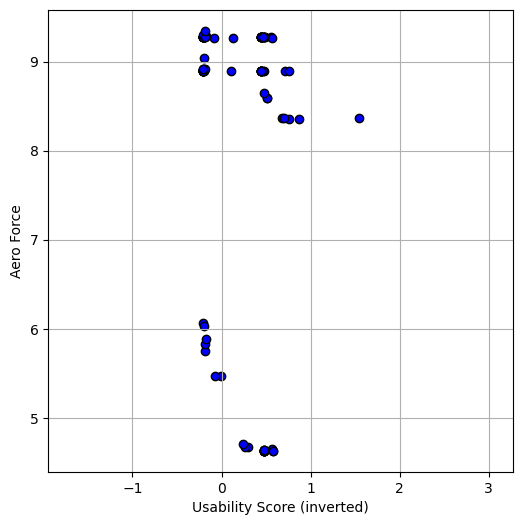

In [ ]:
points = res['y']
x = points[:, 0]
y = points[:, 1]

# Filter out negative y-values
mask = y >= 0
x = x[mask]
y = y[mask]

plt.figure(figsize=(6, 6))
plt.scatter(x, y, c='blue', edgecolors='k')
plt.xlabel("Usability Score (inverted)")
plt.ylabel("Aero Force")
plt.grid(True)
plt.axis("equal") 
plt.show()

In [ ]:
print(res['y'])
print(res['y'].shape)


[[ 5.7076055e-01  4.6458716e+00]
 [ 7.0760936e-01  8.8921165e+00]
 [ 5.8059800e-01  4.6312418e+00]
 [ 4.8614955e-01  9.2741718e+00]
 [ 1.5406473e+00  8.3636589e+00]
 [-8.6211801e-02  9.2697229e+00]
 [ 1.0370529e-01  8.8947067e+00]
 [ 8.6979562e-01  8.3604746e+00]
 [ 5.5737340e-01  9.2715969e+00]
 [ 4.7569108e-01  9.2748470e+00]
 [ 5.7196403e-01  9.2695999e+00]
 [-2.1272779e-01 -2.4645598e+03]
 [ 1.2855315e-01  9.2688847e+00]
 [ 4.7358882e-01  8.8922291e+00]
 [ 4.4188440e-01  8.8922834e+00]
 [-1.9358647e-01  8.8957424e+00]
 [-1.8971574e-01  9.2719069e+00]
 [ 4.4123352e-01  9.2764025e+00]
 [ 5.7702780e-01  4.6328535e+00]
 [-2.1162832e-01  8.8940725e+00]
 [ 4.7197795e-01  9.2732458e+00]
 [ 7.5343329e-01  8.3571663e+00]
 [ 2.9522336e-01  4.6723199e+00]
 [ 4.4328117e-01  8.8928957e+00]
 [ 4.4327134e-01  8.8933115e+00]
 [-2.0637500e-01  8.8980322e+00]
 [ 4.7195148e-01  9.2732372e+00]
 [-2.0729661e-01  9.2750931e+00]
 [ 4.7497195e-01  4.6312647e+00]
 [ 4.4079977e-01  9.2783833e+00]
 [ 7.60049

In [ ]:
def test_general(args, condition, x0, prefs, solver, eval_fn, ref_point):
    problem = bicycle(condition=condition, n_obj=2, eval_fn=eval_fn)

    start_time = time.time()
    res = solver.solve(problem, x=x0, prefs=prefs, args=args, ref_point=ref_point)
    end_time = time.time()
    print(f"Time completed: {end_time - start_time:.2f} seconds")

    x0_np = x0.numpy() if isinstance(x0, torch.Tensor) else x0
    res_x_np = res['x'].numpy() if isinstance(res['x'], torch.Tensor) else res['x']
    assert x0_np.shape == res_x_np.shape, "The shapes of x0 and res['x'] must match"
    num_affected = 0
    for i in range(x0_np.shape[0]):  # Iterate over rows
        diff = np.count_nonzero(res_x_np[i] != x0_np[i])  
        num_affected += diff  

    print('Average Number of parameters affected:', num_affected/x0.shape[0])
    return res

In [ ]:
# aeroEV = [
#     AeroEvaluator(),
# ]
# usableEV = [
#     UsabilityEvaluator(),
# ]

# structuralEV = [
#     StructuralEvaluator(),
# ]

# evaluator_aero, _, _ = construct_tensor_evaluator(aeroEV, data.columns)
# evaluator_usable, _, _ = construct_tensor_evaluator(usableEV, data.columns)
# evaluator_structural, _, _ = construct_tensor_evaluator(structuralEV, data.columns)

# def eval_fn(x, condition): # All scores should be minimised
#     usable_score = 1 - evaluator_usable(x, condition)
#     aero_score = evaluator_aero(x, condition)
#     comb = torch.cat((usable_score, aero_score), dim=1)
#     return comb

# array([1.0 , 25.0 ])